# Imports



In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch

!pip install ta -q
import ta
# from google.colab import userdata
# KAGGLE_API_KEY = userdata.get('KAGGLE_API')
# !export KAGGLE_API_TOKEN={KAGGLE_API_KEY}

  Preparing metadata (setup.py) ... done


# Dataset Processing

## Downlaod shit

In [2]:
def download_and_clean(ticker, start="2000-01-01"):
    df = yf.download(ticker, start=start, auto_adjust=True)
    df.columns = df.columns.droplevel(1)
    df.index.name = 'Date'
    df = df.reset_index()
    df['Date'] = pd.to_datetime(df['Date']).dt.normalize()
    return df

# Download all
df_sp500 = download_and_clean("^GSPC")
df_gold  = download_and_clean("GC=F")
df_oil   = download_and_clean("CL=F")
df_bond  = download_and_clean("^TNX")  # 10-year treasury yield


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## Process shit

In [3]:
df_sp500.keys()

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [4]:
df = df_sp500.copy()

high, low, open, close, volume = df['High'], df['Low'], df['Open'], df['Close'], df['Volume']

# Returns
df['Return'] = df['Close'].pct_change()
df['Return_5d']  = df['Close'].pct_change(5)
df['Return_10d'] = df['Close'].pct_change(10)
df['Return_20d'] = df['Close'].pct_change(20)
df['PerOpen'] = df['Open'].pct_change()
df["PerHigh"] = df['High'].pct_change()
df['PerLow'] = df['Low'].pct_change()

# Volume
df['Volume_Ratio'] = df['Volume'] / df['Volume'].rolling(20).mean()

# Trend
df['SMA_5']  = ta.trend.sma_indicator(df['Close'], window=5)
df['SMA_10'] = ta.trend.sma_indicator(df['Close'], window=10)
df['SMA_20'] = ta.trend.sma_indicator(df['Close'], window=20)
df['SMA_50'] = ta.trend.sma_indicator(df['Close'], window=50)
df['SMA_200'] = ta.trend.sma_indicator(df['Close'], window=200)

# Instead of raw SMA, use distance from price as a percentage
df['SMA_5_dist']  = (df['Close'] - df['SMA_5'])  / df['Close']
df['SMA_10_dist'] = (df['Close'] - df['SMA_10']) / df['Close']
df['SMA_20_dist'] = (df['Close'] - df['SMA_20']) / df['Close']
df['SMA_50_dist'] = (df['Close'] - df['SMA_50']) / df['Close']
df['SMA_200_dist'] = (df['Close'] - df['SMA_200']) / df['Close']

# Add EMA indicators
df['EMA_5']  = ta.trend.ema_indicator(df['Close'], window=5)
df['EMA_10'] = ta.trend.ema_indicator(df['Close'], window=10)
df['EMA_20'] = ta.trend.ema_indicator(df['Close'], window=20)
df['EMA_50'] = ta.trend.ema_indicator(df['Close'], window=50)
df['EMA_200'] = ta.trend.ema_indicator(df['Close'], window=200)

# Normalize as distance from price (same as SMA)
df['EMA_5_dist']  = (df['Close'] - df['EMA_5'])  / df['Close']
df['EMA_10_dist'] = (df['Close'] - df['EMA_10']) / df['Close']
df['EMA_20_dist'] = (df['Close'] - df['EMA_20']) / df['Close']
df['EMA_50_dist'] = (df['Close'] - df['EMA_50']) / df['Close']
df['EMA_200_dist'] = (df['Close'] - df['EMA_200']) / df['Close']

# Positive = short EMA above long EMA (bullish), Negative = bearish
df['EMA_5_20_cross']  = df['EMA_5_dist']  - df['EMA_20_dist']
df['EMA_20_50_cross'] = df['EMA_20_dist'] - df['EMA_50_dist']

# Drop raw EMA
df = df.drop(columns=['EMA_5', 'EMA_10', 'EMA_20', 'EMA_50', 'EMA_200'])

# Drop the raw SMA columns
df = df.drop(columns=['SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'SMA_200'])

df['MACD'] = ta.trend.macd(df['Close'])

df['PSAR_DOWN'] = ta.trend.psar_down(high, low, close) / close
df['PSAR_UP'] = ta.trend.psar_up(high, low, close) / close

df['Bollband_Hband'] = ta.volatility.bollinger_hband(close) / close
df['Bollband_Lband'] = ta.volatility.bollinger_lband(close) / close
df['Bollband_Pband'] = ta.volatility.bollinger_pband(close) / close
df['Bollband_Wband'] = ta.volatility.bollinger_wband(close) / close

df['Stochastic_d'] = ta.momentum.stochrsi_d(close)
df['Stochastic_k'] = ta.momentum.stochrsi_k(close)

# Momentum
df['RSI'] = ta.momentum.rsi(df['Close'], window=14) / 100
df['MFI'] = ta.volume.money_flow_index(high, low, close, volume) / 100
df["CMF"] = ta.volume.chaikin_money_flow(high, low, close, volume)

# Volatility
df['Volatility'] = df['Return'].rolling(10).std()

# Target — next day up or down
df['Future_Up_1d'] = (df['Close'].shift(-1) > df['Close']).astype(int)

In [5]:
df

Price,Date,Close,High,Low,Open,Volume,Return,Return_5d,Return_10d,Return_20d,...,Bollband_Lband,Bollband_Pband,Bollband_Wband,Stochastic_d,Stochastic_k,RSI,MFI,CMF,Volatility,Future_Up_1d
0,2000-01-03,1455.219971,1478.000000,1438.359985,1469.250000,931800000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2000-01-04,1399.420044,1455.219971,1397.430054,1455.219971,1009000000,-0.038345,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2000-01-05,1402.109985,1413.270020,1377.680054,1399.420044,1085500000,0.001922,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,2000-01-06,1403.449951,1411.900024,1392.099976,1402.109985,1092300000,0.000956,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,2000-01-07,1441.469971,1441.469971,1400.729980,1403.449951,1225200000,0.027090,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6609,2026-04-15,7022.950195,7026.240234,6967.129883,6978.169922,5278610000,0.007976,0.035404,0.075734,0.045690,...,0.895007,0.000147,0.001535,0.995938,1.000000,0.693112,0.659642,0.073544,0.007503,1
6610,2026-04-16,7041.279785,7051.229980,7008.520020,7037.779785,5173650000,0.002610,0.031741,0.070865,0.062883,...,0.890031,0.000138,0.001694,0.997969,1.000000,0.700343,0.728978,0.144122,0.007653,1
6611,2026-04-17,7126.060059,7147.520020,7074.549805,7074.549805,6145300000,0.012040,0.045354,0.082545,0.078645,...,0.876545,0.000139,0.001863,1.000000,1.000000,0.731817,0.803839,0.154347,0.007515,0
6612,2026-04-20,7109.140137,7122.649902,7084.410156,7117.049805,4661130000,-0.002374,0.032369,0.075215,0.092625,...,0.879080,0.000128,0.001972,0.994124,0.982371,0.715661,0.806501,0.219801,0.008153,0


In [6]:
df_gold['Gold_Return'] = df_gold['Close'].pct_change()
df_gold['Gold_RSI'] = ta.momentum.rsi(df_gold['Close'], window=14) / 100

# df_gold['Gold_Volume_Ratio'] = df_gold['Volume'] / df_gold['Volume'].rolling(20).mean()
df_oil['Oil_Return']   = df_oil['Close'].pct_change()
df_oil['Oil_Volume_Ratio'] = df_oil['Volume'] / df_oil['Volume'].rolling(20).mean()
df_oil['Oil_RSI'] = ta.momentum.rsi(df_oil['Close'], window=14) / 100

df_bond['Bond_Return'] = df_bond['Close'].pct_change()
df_bond['Bond_Yield']  = df_bond['Close']  / 10 # yield level is meaningful too
df_bond['Bond_RSI'] = ta.momentum.rsi(df_bond['Close'], window=14) / 100

# Merge all
df = df.merge(df_gold[['Date', 'Gold_Return', 'Gold_RSI']], on='Date', how='left') \
       .merge(df_oil[['Date', 'Oil_Return', 'Oil_Volume_Ratio', 'Oil_RSI']],   on='Date', how='left') \
       .merge(df_bond[['Date', 'Bond_Return', 'Bond_Yield', 'Bond_RSI']], on='Date', how='left')

# Forward fill gaps (holidays etc.)
df = df.ffill().dropna().reset_index(drop=True)

print(df.shape)
df

(6415, 48)


Price,Date,Close,High,Low,Open,Volume,Return,Return_5d,Return_10d,Return_20d,...,Volatility,Future_Up_1d,Gold_Return,Gold_RSI,Oil_Return,Oil_Volume_Ratio,Oil_RSI,Bond_Return,Bond_Yield,Bond_RSI
0,2000-10-16,1374.619995,1379.479980,1365.060059,1374.170044,1005400000,0.000327,-0.019550,-0.042897,-0.048383,...,0.016412,0,-0.003304,0.475578,-0.055635,0.823190,0.502913,0.004374,0.5740,0.420445
1,2000-10-17,1349.969971,1380.989990,1342.339966,1374.619995,1161500000,-0.017932,-0.026712,-0.053622,-0.075300,...,0.016972,0,-0.001473,0.467178,-0.004532,1.044063,0.496950,-0.013066,0.5665,0.349323
2,2000-10-18,1342.130005,1356.650024,1305.790039,1349.969971,1441700000,-0.005808,-0.016459,-0.064274,-0.075248,...,0.016538,1,-0.002951,0.450056,0.018209,0.753456,0.521395,-0.001412,0.5657,0.342664
3,2000-10-19,1388.760010,1389.930054,1342.130005,1342.130005,1297900000,0.034743,0.044353,-0.033085,-0.041607,...,0.021053,1,-0.000740,0.445659,-0.017884,0.814425,0.495466,-0.000884,0.5652,0.338323
4,2000-10-20,1396.930054,1408.469971,1382.189941,1388.760010,1177400000,0.005883,0.016563,-0.008559,-0.035749,...,0.020435,0,0.004073,0.475985,0.040971,1.120037,0.549723,-0.002831,0.5636,0.324172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6410,2026-04-15,7022.950195,7026.240234,6967.129883,6978.169922,5278610000,0.007976,0.035404,0.075734,0.045690,...,0.007503,1,-0.005181,0.518526,0.000110,0.667511,0.474259,0.006109,0.4282,0.502397
6411,2026-04-16,7041.279785,7051.229980,7008.520020,7037.779785,5173650000,0.002610,0.031741,0.070865,0.062883,...,0.007653,1,-0.003042,0.510671,0.037244,0.536895,0.506308,0.006305,0.4309,0.530941
6412,2026-04-17,7126.060059,7147.520020,7074.549805,7074.549805,6145300000,0.012040,0.045354,0.082545,0.078645,...,0.007515,0,0.015088,0.547202,-0.114479,0.322262,0.418677,-0.014621,0.4246,0.464051
6413,2026-04-20,7109.140137,7122.649902,7084.410156,7117.049805,4661130000,-0.002374,0.032369,0.075215,0.092625,...,0.008153,0,-0.010499,0.517796,0.068694,0.335419,0.471064,0.000942,0.4250,0.468629


In [7]:
DROP_COLS =  ['Volume', 'Close', 'Open', 'High', 'Low'] # , 'Bollband_Lband', 'Return_20d', 'RSI', 'Return_10d', 'EMA_5_20_cross']  # raw OHLCV not needed if using returns/indicators
_df = df.drop(columns=DROP_COLS)
_df

Price,Date,Return,Return_5d,Return_10d,Return_20d,PerOpen,PerHigh,PerLow,Volume_Ratio,SMA_5_dist,...,Volatility,Future_Up_1d,Gold_Return,Gold_RSI,Oil_Return,Oil_Volume_Ratio,Oil_RSI,Bond_Return,Bond_Yield,Bond_RSI
0,2000-10-16,0.000327,-0.019550,-0.042897,-0.048383,0.033381,0.003864,0.028619,0.893860,0.006245,...,0.016412,0,-0.003304,0.475578,-0.055635,0.823190,0.502913,0.004374,0.5740,0.420445
1,2000-10-17,-0.017932,-0.026712,-0.053622,-0.075300,0.000327,0.001095,-0.016644,1.026409,-0.006412,...,0.016972,0,-0.001473,0.467178,-0.004532,1.044063,0.496950,-0.013066,0.5665,0.349323
2,2000-10-18,-0.005808,-0.016459,-0.064274,-0.075248,-0.017932,-0.017625,-0.027229,1.255290,-0.008944,...,0.016538,1,-0.002951,0.450056,0.018209,0.753456,0.521395,-0.001412,0.5657,0.342664
3,2000-10-19,0.034743,0.044353,-0.033085,-0.041607,-0.005808,0.024531,0.027830,1.120691,0.016439,...,0.021053,1,-0.000740,0.445659,-0.017884,0.814425,0.495466,-0.000884,0.5652,0.338323
4,2000-10-20,0.005883,0.016563,-0.008559,-0.035749,0.034743,0.013339,0.029848,1.016999,0.018933,...,0.020435,0,0.004073,0.475985,0.040971,1.120037,0.549723,-0.002831,0.5636,0.324172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6410,2026-04-15,0.007976,0.035404,0.075734,0.045690,0.009836,0.008153,0.008973,0.971566,0.016991,...,0.007503,1,-0.005181,0.518526,0.000110,0.667511,0.474259,0.006109,0.4282,0.502397
6411,2026-04-16,0.002610,0.031741,0.070865,0.062883,0.008542,0.003557,0.005941,0.953141,0.013397,...,0.007653,1,-0.003042,0.510671,0.037244,0.536895,0.506308,0.006305,0.4309,0.530941
6412,2026-04-17,0.012040,0.045354,0.082545,0.078645,0.005225,0.013656,0.009421,1.130358,0.016458,...,0.007515,0,0.015088,0.547202,-0.114479,0.322262,0.418677,-0.014621,0.4246,0.464051
6413,2026-04-20,-0.002374,0.032369,0.075215,0.092625,0.006007,-0.003480,0.001394,0.901858,0.007846,...,0.008153,0,-0.010499,0.517796,0.068694,0.335419,0.471064,0.000942,0.4250,0.468629


In [8]:
# Check for NaN values
print("=== NaN Count per Column ===")
print(df.isna().sum())

print(f"\n=== Total NaN rows: {df.isna().any(axis=1).sum()} ===")

# See which rows have NaN
print("\n=== Sample NaN rows ===")
print(df[df.isna().any(axis=1)].head(10))

=== NaN Count per Column ===
Price
Date                0
Close               0
High                0
Low                 0
Open                0
Volume              0
Return              0
Return_5d           0
Return_10d          0
Return_20d          0
PerOpen             0
PerHigh             0
PerLow              0
Volume_Ratio        0
SMA_5_dist          0
SMA_10_dist         0
SMA_20_dist         0
SMA_50_dist         0
SMA_200_dist        0
EMA_5_dist          0
EMA_10_dist         0
EMA_20_dist         0
EMA_50_dist         0
EMA_200_dist        0
EMA_5_20_cross      0
EMA_20_50_cross     0
MACD                0
PSAR_DOWN           0
PSAR_UP             0
Bollband_Hband      0
Bollband_Lband      0
Bollband_Pband      0
Bollband_Wband      0
Stochastic_d        0
Stochastic_k        0
RSI                 0
MFI                 0
CMF                 0
Volatility          0
Future_Up_1d        0
Gold_Return         0
Gold_RSI            0
Oil_Return          0
Oil_Volume_Ratio   

In [9]:
import torch

SEQUENCE_LENGTH = 60

target_cols  = ['Future_Up_1d']

n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

test_prices = test_df['Close'].values[SEQUENCE_LENGTH:]
test_dates  = test_df['Date'].values[SEQUENCE_LENGTH:]

train_df = train_df.drop(columns=DROP_COLS)
val_df   = val_df.drop(columns=DROP_COLS)
test_df  = test_df.drop(columns=DROP_COLS)

feature_cols = [col for col in train_df.columns if col not in ['Date'] + target_cols]

def create_sequences(data, feature_cols, target_cols, seq_len):
    X, y = [], []
    features = data[feature_cols].values
    targets  = data[target_cols].values

    for i in range(seq_len, len(data)):
        X.append(features[i-seq_len:i])  # last seq_len days as input
        y.append(targets[i])             # next day as target

    X = torch.tensor(X, dtype=torch.float32)  # (samples, seq_len, features)
    y = torch.tensor(y, dtype=torch.float32)  # (samples, 1)
    return X, y


# Normalize using train set only
train_features = torch.tensor(train_df[feature_cols].values, dtype=torch.float32)
mean = train_features.mean(dim=0)
std  = train_features.std(dim=0)
std[std == 0] = 1

def normalize_df(data, feature_cols, mean, std):
    df_norm = data.copy()
    df_norm[feature_cols] = (data[feature_cols].values - mean.numpy()) / std.numpy()
    return df_norm

train_df_norm = normalize_df(train_df, feature_cols, mean, std)
val_df_norm   = normalize_df(val_df,   feature_cols, mean, std)
test_df_norm  = normalize_df(test_df,  feature_cols, mean, std)

# Create sequences
X_train, y_train = create_sequences(train_df_norm, feature_cols, target_cols, SEQUENCE_LENGTH)
X_val,   y_val   = create_sequences(val_df_norm,   feature_cols, target_cols, SEQUENCE_LENGTH)
X_test,  y_test  = create_sequences(test_df_norm,  feature_cols, target_cols, SEQUENCE_LENGTH)

y_train = y_train.squeeze(1).long()
y_val   = y_val.squeeze(1).long()
y_test  = y_test.squeeze(1).long()

def to_one_hot(y, num_classes=2):
    return torch.zeros(len(y), num_classes).scatter_(1, y.unsqueeze(1), 1)

y_train = to_one_hot(y_train)
y_val   = to_one_hot(y_val)
y_test  = to_one_hot(y_test)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   | y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")
print(f"test_prices: {test_prices.shape} | test_dates: {test_dates.shape}")

/tmp/ipykernel_1384/1918066770.py:33: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X = torch.tensor(X, dtype=torch.float32)  # (samples, seq_len, features)


X_train: torch.Size([4430, 60, 41]) | y_train: torch.Size([4430, 2])
X_val:   torch.Size([902, 60, 41])   | y_val:   torch.Size([902, 2])
X_test:  torch.Size([903, 60, 41])  | y_test:  torch.Size([903, 2])
test_prices: (903,) | test_dates: (903,)


In [10]:
print(df['Future_Up_1d'].value_counts(normalize=True))

Future_Up_1d
1    0.539049
0    0.460951
Name: proportion, dtype: float64


In [11]:
train_df

Price,Date,Return,Return_5d,Return_10d,Return_20d,PerOpen,PerHigh,PerLow,Volume_Ratio,SMA_5_dist,...,Volatility,Future_Up_1d,Gold_Return,Gold_RSI,Oil_Return,Oil_Volume_Ratio,Oil_RSI,Bond_Return,Bond_Yield,Bond_RSI
0,2000-10-16,0.000327,-0.019550,-0.042897,-0.048383,0.033381,0.003864,0.028619,0.893860,0.006245,...,0.016412,0,-0.003304,0.475578,-0.055635,0.823190,0.502913,0.004374,0.5740,0.420445
1,2000-10-17,-0.017932,-0.026712,-0.053622,-0.075300,0.000327,0.001095,-0.016644,1.026409,-0.006412,...,0.016972,0,-0.001473,0.467178,-0.004532,1.044063,0.496950,-0.013066,0.5665,0.349323
2,2000-10-18,-0.005808,-0.016459,-0.064274,-0.075248,-0.017932,-0.017625,-0.027229,1.255290,-0.008944,...,0.016538,1,-0.002951,0.450056,0.018209,0.753456,0.521395,-0.001412,0.5657,0.342664
3,2000-10-19,0.034743,0.044353,-0.033085,-0.041607,-0.005808,0.024531,0.027830,1.120691,0.016439,...,0.021053,1,-0.000740,0.445659,-0.017884,0.814425,0.495466,-0.000884,0.5652,0.338323
4,2000-10-20,0.005883,0.016563,-0.008559,-0.035749,0.034743,0.013339,0.029848,1.016999,0.018933,...,0.020435,0,0.004073,0.475985,0.040971,1.120037,0.549723,-0.002831,0.5636,0.324172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4485,2018-08-15,-0.007602,-0.013763,0.001781,0.000977,0.000025,-0.005332,-0.008523,1.108552,-0.005341,...,0.005092,1,-0.012992,0.207127,-0.030280,1.114789,0.361475,-0.014853,0.2852,0.411365
4486,2018-08-16,0.007919,-0.004517,0.004764,0.012908,0.001234,0.007970,0.010330,0.980496,0.003465,...,0.005475,1,-0.001104,0.203486,0.006922,0.725507,0.384141,0.006662,0.2871,0.440754
4487,2018-08-17,0.003323,0.005947,0.003443,0.017239,0.002430,0.001803,0.000809,0.924416,0.005584,...,0.005379,1,0.000255,0.206951,0.006874,0.334803,0.406818,0.000697,0.2873,0.443901
4488,2018-08-20,0.002428,0.012445,0.002333,0.017838,0.005500,0.001446,0.005960,0.841250,0.005534,...,0.005317,1,0.008755,0.316819,0.007889,0.230116,0.432807,-0.017403,0.2823,0.385492


# Model

In [ ]:
import torch
import torch.nn as nn

class RotaryEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer('inv_freq', inv_freq)

    def forward(self, seq_len, device):
        t     = torch.arange(seq_len, device=device).float()
        freqs = torch.einsum('i, j -> ij', t, self.inv_freq)   # (seq_len, dim/2)
        emb   = torch.cat([freqs, freqs], dim=-1)              # (seq_len, dim)
        return emb.cos(), emb.sin()

def rotate_half(x):
    x1 = x[..., :x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2:]
    return torch.cat([-x2, x1], dim=-1)

def apply_rotary_emb(q, k, cos, sin):
    # q, k: (batch, heads, seq_len, head_dim)
    # cos, sin: (seq_len, head_dim)
    cos = cos.unsqueeze(0).unsqueeze(0)  # (1, 1, seq_len, head_dim)
    sin = sin.unsqueeze(0).unsqueeze(0)
    q   = (q * cos) + (rotate_half(q) * sin)
    k   = (k * cos) + (rotate_half(k) * sin)
    return q, k

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads=8):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads

        if embed_dim % num_heads != 0:
            raise ValueError(
                f"embedding dimension = {embed_dim} should be divisible by number of heads = {num_heads}"
            )

        self.projection_dim = embed_dim // num_heads
        self.scale = math.sqrt(self.projection_dim)

        self.query_dense = nn.Linear(embed_dim, embed_dim)
        self.key_dense = nn.Linear(embed_dim, embed_dim)
        self.value_dense = nn.Linear(embed_dim, embed_dim)
        self.combine_heads = nn.Linear(embed_dim, embed_dim)
        self.rotary_emb   = RotaryEmbedding(self.projection_dim)

    def attention(self, query, key, value, attn_mask=None):
        """
        query: (batch_size, num_heads, seq_len, projection_dim)
        key:   (batch_size, num_heads, seq_len, projection_dim)
        value: (batch_size, num_heads, seq_len, projection_dim)
        attn_mask: (batch_size, num_heads, seq_len, seq_len) — True/1 means IGNORE (masked out)
        """
        seq_len = query.size(2)
        # (batch_size, num_heads, seq_len, seq_len)
        score = torch.matmul(query, key.transpose(-2, -1)) / self.scale
        # print("ATTN SCORE", score.shape)

        causal_mask = torch.tril(torch.ones((seq_len, seq_len))).to(query.device)
        score = score.masked_fill(causal_mask==0, float("-inf"))

        if attn_mask is not None:
            # Fill masked positions with -inf so softmax zeroes them out
            score = score.masked_fill(attn_mask.bool(), float("-inf"))

        attn_weights = F.softmax(score.clamp(min=-1e9), dim=-1)
        output = torch.matmul(attn_weights, value)
        return output, attn_weights

    def separate_heads(self, x, batch_size):
        # x: (batch_size, seq_len, embed_dim)
        x = x.view(batch_size, -1, self.num_heads, self.projection_dim)
        # -> (batch_size, num_heads, seq_len, projection_dim)
        return x.permute(0, 2, 1, 3)

    def forward(self, inputs, attn_mask=None):
        """
        inputs:    (batch_size, seq_len, embed_dim)
        attn_mask: (batch_size, seq_len) — 1/True = ignore, 0/False = keep
        """
        # print(inputs)
        batch_size, seq_len, _ = inputs.shape

        if attn_mask is not None:
            # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
            attn_mask = attn_mask.unsqueeze(1).unsqueeze(2)
            # (batch_size, num_heads, seq_len, seq_len)
            attn_mask = attn_mask.expand(batch_size, self.num_heads, seq_len, seq_len)

        query = self.query_dense(inputs)   # (batch_size, seq_len, embed_dim)
        key   = self.key_dense(inputs)
        value = self.value_dense(inputs)

        query = self.separate_heads(query, batch_size)  # (batch_size, num_heads, seq_len, projection_dim)
        key   = self.separate_heads(key,   batch_size)
        value = self.separate_heads(value, batch_size)

        # Apply RoPE to query and key
        cos, sin = self.rotary_emb(seq_len, device=inputs.device)
        query, key = apply_rotary_emb(query, key, cos, sin)

        attention, attn_weights = self.attention(query, key, value, attn_mask)
        # print("ATTENTIIN", attention.shape)

        # (batch_size, seq_len, num_heads, projection_dim)
        attention = attention.permute(0, 2, 1, 3).contiguous()
        # (batch_size, seq_len, embed_dim)
        concat_attention = attention.view(batch_size, -1, self.embed_dim)

        output = self.combine_heads(concat_attention)

        return output, attn_weights


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim),
        )
        self.layernorm1 = nn.LayerNorm(embed_dim, eps=1e-6)
        self.layernorm2 = nn.LayerNorm(embed_dim, eps=1e-6)
        self.dropout1 = nn.Dropout(rate)
        self.dropout2 = nn.Dropout(rate)

    def forward(self, inputs, attn_mask=None):
        # self.train(training)

        attn_output, attn_weights = self.att(inputs, attn_mask)
        attn_output = self.dropout1(attn_output)
        # print(attn_output)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output)
        output = self.layernorm2(out1 + ffn_output)

        return output, attn_weights

## My ass

In [ ]:
import torch.nn as nn

# THIS SHIT DOESNT FUCKING WORK AAAAAAAAAAAAAAAAAAAA
class StockModel(nn.Module):
    def __init__(self, input_dim, embed_dim, num_heads, dropout):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, embed_dim)
        # self.cls_token  = nn.Parameter(torch.zeros(1, 1, embed_dim))

        self.trans = TransformerBlock(embed_dim=embed_dim, num_heads=num_heads, ff_dim=embed_dim, rate=dropout)

        self.LSTM = nn.LSTM(embed_dim, embed_dim, 2, batch_first=True, bidirectional=False)
        self.batch_norm = nn.BatchNorm1d(embed_dim)
        self.norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
        )

        self.out = nn.Sequential(
            nn.Linear(embed_dim, 2),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        B = x.shape[0]
        x = self.input_proj(x) # (Batch, seq, D)

        x, _ = self.trans(x) # (batch, seq, D)

        x, (h, c) = self.LSTM(x)
        h = h[1: ].squeeze(0) # (batch, dim)
        h = self.batch_norm(h) # (batch, dim)
        h = self.norm(h)
        h = self.dropout(h)

        h = self.ffn(h) + h # (Batch, 1)
        out = self.out(h)

        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = StockModel(
    input_dim  = X_train.shape[2],
    embed_dim  = 256,
    num_heads  = 2,
    dropout    = 0.3
).to(device)

Using device: cuda


## StockFormer

In [ ]:
import torch.nn as nn

# This sucks.
class StockModel(nn.Module):
    def __init__(self, input_dim, embed_dim, num_heads, num_layers, dropout):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, embed_dim)
        # self.cls_token  = nn.Parameter(torch.zeros(1, 1, embed_dim))

        self.layers = nn.ModuleList([
            TransformerBlock(embed_dim=embed_dim, num_heads=num_heads, ff_dim=embed_dim, rate=dropout)
            for _ in range(num_layers)
        ])

        self.out = nn.Sequential(
            nn.Linear(embed_dim, 2),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        B = x.shape[0]
        x = self.input_proj(x) # (Batch, seq, D)

        # Append CLS
        # cls = self.cls_token.expand(B, -1, -1) # (Batch, 1, D)
        # x = torch.cat([x, cls], dim=1)

        for layer in self.layers:
            x, _ = layer(x)

        last = x[:, -1, :] # (Batch, D)

        # last = self.dropout_last(last)

        output = self.out(last) # (Batch, 1)

        return output

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = StockModel(
    input_dim  = X_train.shape[2],
    embed_dim  = 256,
    num_heads  = 2,
    num_layers = 2,
    dropout    = 0.4
).to(device)

Using device: cuda


## LSTM

In [12]:
import torch
import torch.nn as nn
torch.manual_seed(4)

# Use this model!
class StockModel(nn.Module):
    def __init__(self, input_dim, embed_dim, dropout):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, embed_dim)
        self.LSTM = nn.LSTM(
            embed_dim, embed_dim, 2, batch_first=True, bidirectional=False, dropout=dropout
        )
        self.batch_norm = nn.BatchNorm1d(embed_dim)
        self.norm = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim),
        )
        self.out = nn.Sequential(
            nn.Linear(embed_dim, 2),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        x = self.input_proj(x) # (batch, seq, dim)
        x, (h, c) = self.LSTM(x)
        # h: (2, batch, dim)
        h = h[-1] # (batch, dim)
        h = self.batch_norm(h) # (batch, dim)
        h = self.norm(h)
        h = self.dropout(h)

        h = self.norm2(self.ffn(h) + h)
        out = self.out(h)

        return out


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = StockModel(
    input_dim  = X_train.shape[2],
    embed_dim  = 256,
    dropout    = 0.25
).to(device)

Using device: cuda


# Train & Test

In [ ]:
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn

# Hyperparameters
BATCH_SIZE   = 64
EPOCHS       = 1000
LEARNING_RATE = 1e-3
PATIENCE     = 10  # early stopping patience

# DataLoaders
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)

# Loss, optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=4, factor=0.5)

# Early stopping variables
best_val_loss   = float('inf')
patience_counter = 0
best_model_state = None

# Training loop
for epoch in range(EPOCHS):

    # --- Train ---
    model.train()
    train_loss, train_correct = 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        output = model(X_batch)                   # (Batch, 1)
        loss   = criterion(output, y_batch)
        loss.backward()
        optimizer.step()


        train_loss    += loss.item()
        preds          = output.argmax(dim=1) # (torch.sigmoid(output) > 0.5).float()
        targets = y_batch.argmax(dim=1)
        train_correct += (preds == targets).sum().item() # correct += (preds == y_batch).sum().item()

    train_loss /= len(train_loader)
    train_acc   = train_correct / len(X_train)

    # --- Validation ---
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            output = model(X_batch)
            loss   = criterion(output, y_batch)

            val_loss    += loss.item()
            preds        = output.argmax(dim=1) # (torch.sigmoid(output) > 0.5).float()
            targets = y_batch.argmax(dim=1)
            val_correct += (preds == targets).sum().item() # correct += (preds == y_batch).sum().item()

    val_loss /= len(val_loader)
    val_acc   = val_correct / len(X_val)

    print(f"Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # --- Early Stopping ---
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        best_model_state = model.state_dict()  # save best weights
        print(f"           ✅ Best model saved (val_loss: {best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⛔ Early stopping at epoch {epoch+1}")
            break
    scheduler.step(val_loss)
# Restore best model
model.load_state_dict(best_model_state)
print("✅ Best model restored!")

Epoch 001 | Train Loss: 0.7408 | Train Acc: 0.5227 | Val Loss: 0.7688 | Val Acc: 0.5477
           ✅ Best model saved (val_loss: 0.7688)
Epoch 002 | Train Loss: 0.7049 | Train Acc: 0.5319 | Val Loss: 0.7161 | Val Acc: 0.5488
           ✅ Best model saved (val_loss: 0.7161)
Epoch 003 | Train Loss: 0.6944 | Train Acc: 0.5304 | Val Loss: 0.7162 | Val Acc: 0.5477
Epoch 004 | Train Loss: 0.6870 | Train Acc: 0.5475 | Val Loss: 0.7186 | Val Acc: 0.5344
Epoch 005 | Train Loss: 0.6854 | Train Acc: 0.5482 | Val Loss: 0.7329 | Val Acc: 0.5554
Epoch 006 | Train Loss: 0.6771 | Train Acc: 0.5633 | Val Loss: 0.7227 | Val Acc: 0.5532
Epoch 007 | Train Loss: 0.6705 | Train Acc: 0.5721 | Val Loss: 0.7480 | Val Acc: 0.5466
Epoch 008 | Train Loss: 0.6598 | Train Acc: 0.5913 | Val Loss: 0.7492 | Val Acc: 0.5299
Epoch 009 | Train Loss: 0.6454 | Train Acc: 0.6191 | Val Loss: 0.7802 | Val Acc: 0.5266
Epoch 010 | Train Loss: 0.6355 | Train Acc: 0.6250 | Val Loss: 0.7739 | Val Acc: 0.5399
Epoch 011 | Train Loss

In [ ]:
model.state_dict()

In [ ]:
model.load_state_dict(best_model_state)
print("✅ Best model restored!")

✅ Best model restored!


In [13]:
model.load_state_dict(torch.load("LSTM(2).pth"))

<All keys matched successfully>

In [ ]:
torch.save(model.state_dict(), "LSTM.pth")

In [14]:
with torch.no_grad():
    output = model(X_test.to(device))
    preds   = output.argmax(dim=1)
    # print(preds)
    targets = y_test.argmax(dim=1).to(device)
    test_acc = (preds == targets).sum().item() / len(y_test)
    print(f"Predicted 1s: {(preds==1).sum().item()}")
    print(f"Predicted 0s: {(preds==0).sum().item()}")
    print(f"Actual 1s:    {(y_test.argmax(dim=1)==1).sum().item()}")
    print(f"Actual 0s:    {(y_test.argmax(dim=1)==0).sum().item()}")
    print(f"Test Accuracy: {test_acc:.4f}")

Predicted 1s: 502
Predicted 0s: 401
Actual 1s:    492
Actual 0s:    411
Test Accuracy: 0.5238


In [ ]:

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

with torch.no_grad():
    output = model(X_test.to(device))
    preds  = output.argmax(dim=1).cpu().numpy()
    actual = y_test.argmax(dim=1).cpu().numpy()

# Full report
print(classification_report(actual, preds, target_names=['Down (0)', 'Up (1)']))

# Confusion matrix
cm = confusion_matrix(actual, preds)
print("Confusion Matrix:")
print(f"                Predicted Down  Predicted Up")
print(f"Actual Down     {cm[0][0]:^14}  {cm[0][1]:^12}")
print(f"Actual Up       {cm[1][0]:^14}  {cm[1][1]:^12}")

              precision    recall  f1-score   support

    Down (0)       0.48      0.51      0.50       410
      Up (1)       0.57      0.55      0.56       493

    accuracy                           0.53       903
   macro avg       0.53      0.53      0.53       903
weighted avg       0.53      0.53      0.53       903

Confusion Matrix:
                Predicted Down  Predicted Up
Actual Down          208            202     
Actual Up            222            271     


# GRAPH VISUALIZATION

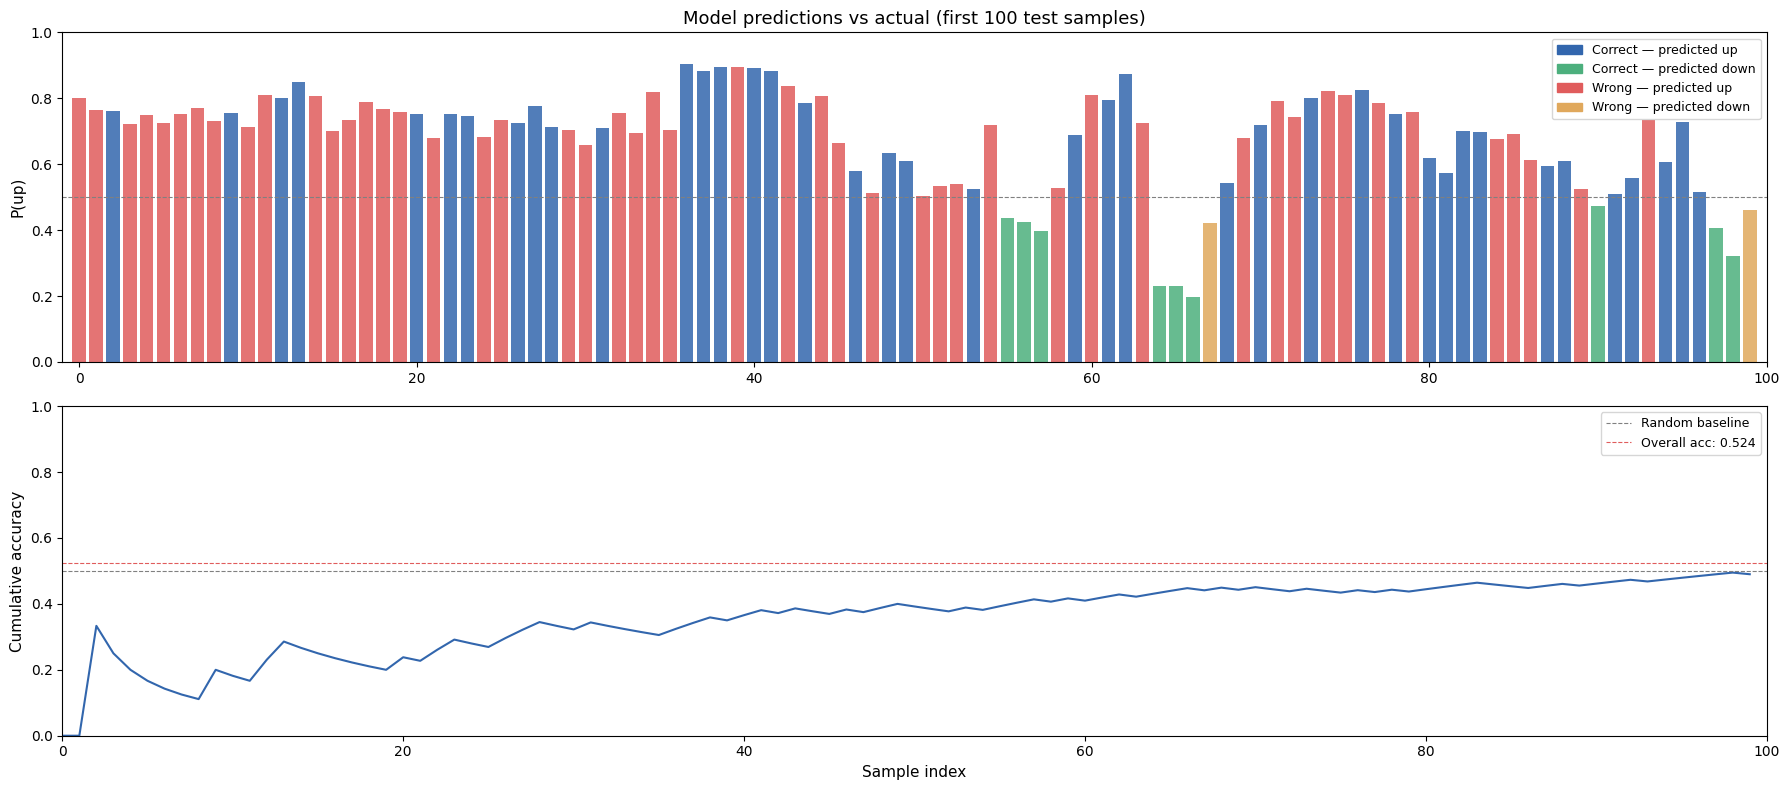

Total samples:    903
Overall accuracy: 0.5238
Predicted up:     508 (56.3%)
Predicted down:   395 (43.7%)
Actual up:        492 (54.5%)
Actual down:      411 (45.5%)


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

with torch.no_grad():
    output = model(X_test.to(device))
    probs  = output[:, 1].cpu().numpy()
    preds  = output.argmax(dim=1).cpu().numpy()
    actual = y_test.argmax(dim=1).cpu().numpy()

correct_mask = preds == actual
colors = []
for p, c in zip(preds, correct_mask):
    if c and p == 1:
        colors.append('#3266ad')   # correct up — blue
    elif c and p == 0:
        colors.append('#4caf7d')   # correct down — green
    elif not c and p == 1:
        colors.append('#e05c5c')   # wrong up — red
    else:
        colors.append('#e0a85c')   # wrong down — orange

n_show = 100  # how many samples to show, change this
fig, axes = plt.subplots(2, 1, figsize=(18, 8))

# --- Plot 1: Prediction bar chart ---
ax1 = axes[0]
x = np.arange(n_show)
ax1.bar(x, probs[:n_show], color=colors[:n_show], width=0.8, alpha=0.85)
ax1.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Decision boundary')
ax1.set_ylabel('P(up)', fontsize=11)
ax1.set_title(f'Model predictions vs actual (first {n_show} test samples)', fontsize=13)
ax1.set_ylim(0, 1)
ax1.set_xlim(-1, n_show)

legend_patches = [
    mpatches.Patch(color='#3266ad', label='Correct — predicted up'),
    mpatches.Patch(color='#4caf7d', label='Correct — predicted down'),
    mpatches.Patch(color='#e05c5c', label='Wrong — predicted up'),
    mpatches.Patch(color='#e0a85c', label='Wrong — predicted down'),
]
ax1.legend(handles=legend_patches, fontsize=9, loc='upper right')

# --- Plot 2: Cumulative accuracy ---
ax2 = axes[1]
cumulative_acc = np.cumsum(correct_mask[:n_show]) / np.arange(1, n_show + 1)
ax2.plot(cumulative_acc, color='#3266ad', linewidth=1.5)
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Random baseline')
ax2.axhline(correct_mask.mean(), color='#e05c5c', linestyle='--', linewidth=0.8, label=f'Overall acc: {correct_mask.mean():.3f}')
ax2.set_ylabel('Cumulative accuracy', fontsize=11)
ax2.set_xlabel('Sample index', fontsize=11)
ax2.set_ylim(0, 1)
ax2.set_xlim(0, n_show)
ax2.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

# Summary stats
print(f"Total samples:    {len(preds)}")
print(f"Overall accuracy: {correct_mask.mean():.4f}")
print(f"Predicted up:     {(preds==1).sum()} ({(preds==1).mean()*100:.1f}%)")
print(f"Predicted down:   {(preds==0).sum()} ({(preds==0).mean()*100:.1f}%)")
print(f"Actual up:        {(actual==1).sum()} ({(actual==1).mean()*100:.1f}%)")
print(f"Actual down:      {(actual==0).sum()} ({(actual==0).mean()*100:.1f}%)")

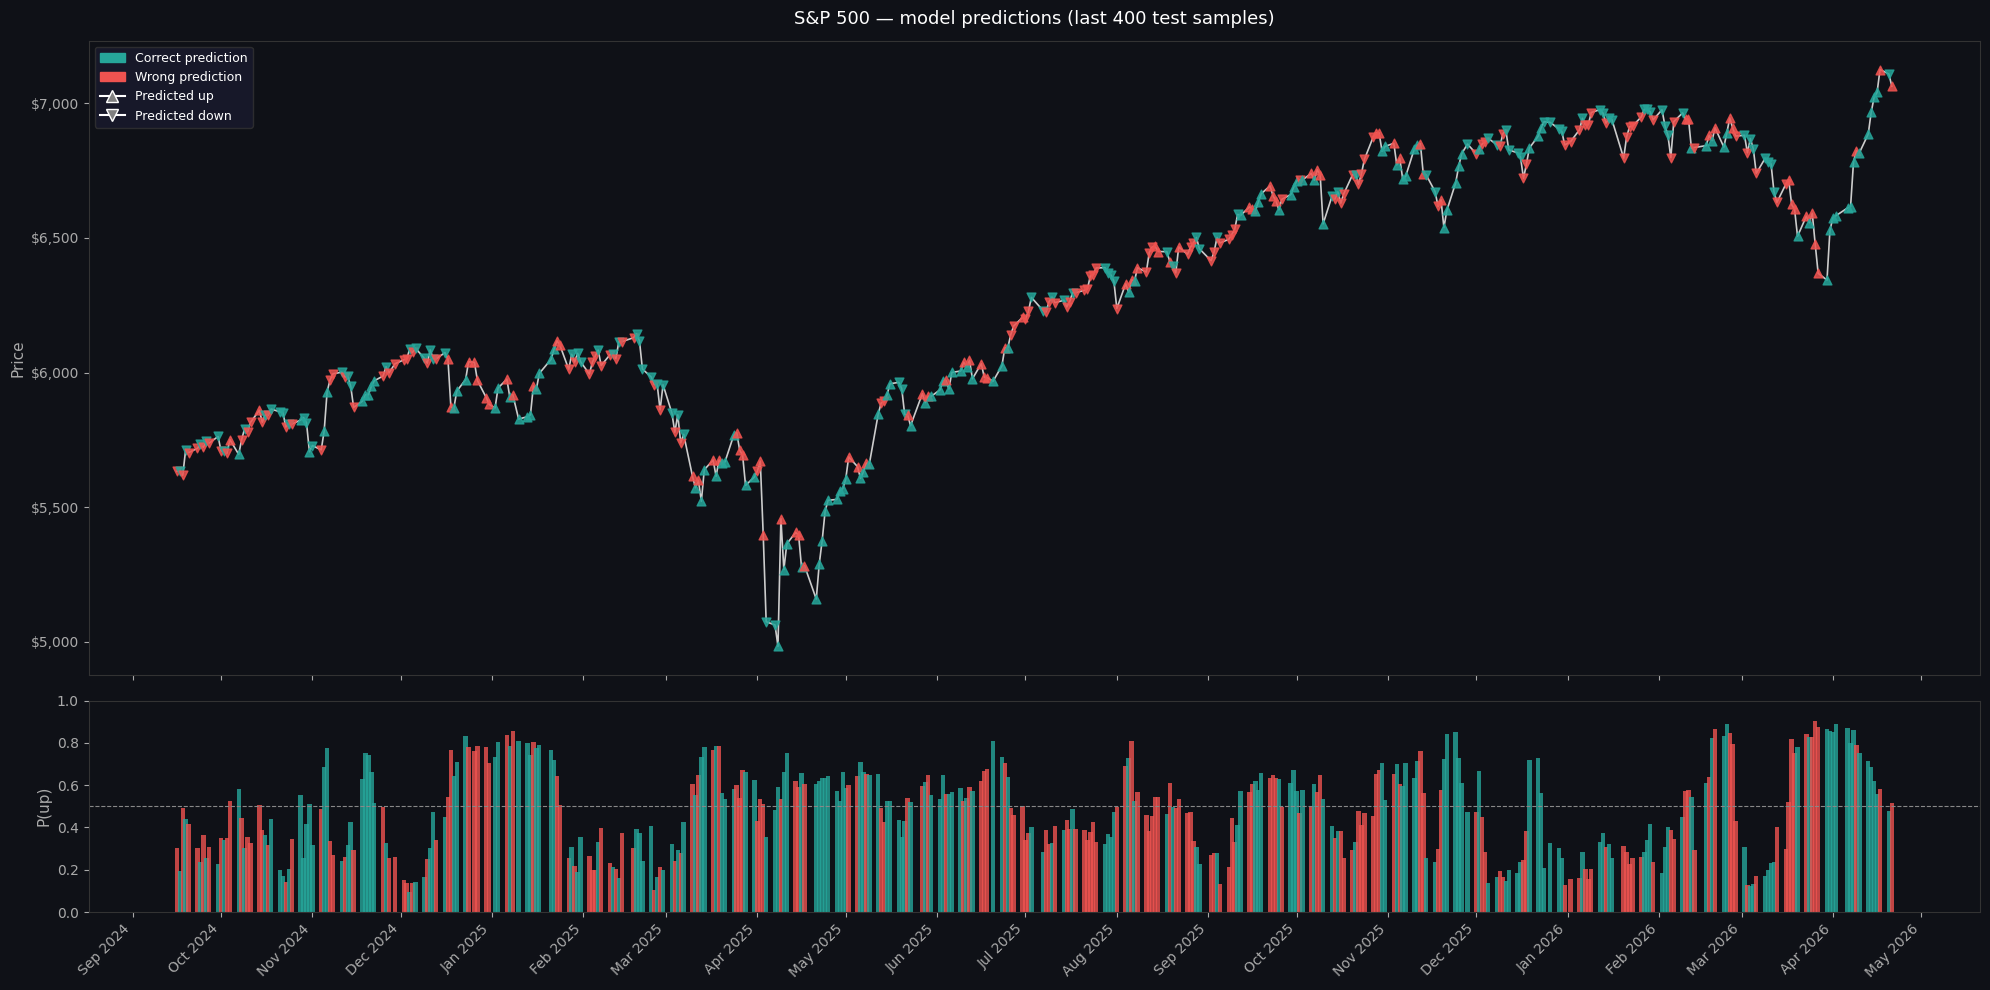

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

with torch.no_grad():
    output = model(X_test.to(device))
    probs  = output[:, 1].cpu().numpy()
    preds  = output.argmax(dim=1).cpu().numpy()
    actual = y_test.argmax(dim=1).cpu().numpy()

correct_mask = preds == actual
n_show = 400  # change this to see more

# Slice to n_show
dates  = pd.to_datetime(test_dates[-n_show:])
prices = test_prices[-n_show:]
p      = preds[-n_show:]
prob   = probs[-n_show:]
corr   = correct_mask[-n_show:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)
fig.patch.set_facecolor('#0f1117')
for ax in (ax1, ax2):
    ax.set_facecolor('#0f1117')
    ax.tick_params(colors='#aaaaaa')
    ax.yaxis.label.set_color('#aaaaaa')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

# --- Plot 1: Price line + prediction markers ---
ax1.plot(dates, prices, color='#cccccc', linewidth=1.2, zorder=1)

for i in range(len(dates)):
    if p[i] == 1 and corr[i]:      # predicted up, correct
        marker, color = '^', '#26a69a'
    elif p[i] == 0 and corr[i]:    # predicted down, correct
        marker, color = 'v', '#26a69a'
    elif p[i] == 1 and not corr[i]: # predicted up, wrong
        marker, color = '^', '#ef5350'
    else:                           # predicted down, wrong
        marker, color = 'v', '#ef5350'

    ax1.scatter(dates[i], prices[i], marker=marker, color=color,
                s=40, zorder=2, alpha=0.85)

ax1.set_ylabel('Price', fontsize=11)
ax1.set_title(f'S&P 500 — model predictions (last {n_show} test samples)',
              fontsize=13, color='white', pad=12)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

legend_patches = [
    mpatches.Patch(color='#26a69a', label='Correct prediction'),
    mpatches.Patch(color='#ef5350', label='Wrong prediction'),
    plt.Line2D([0],[0], marker='^', color='w', markerfacecolor='gray', markersize=8, label='Predicted up'),
    plt.Line2D([0],[0], marker='v', color='w', markerfacecolor='gray', markersize=8, label='Predicted down'),
]
ax1.legend(handles=legend_patches, fontsize=9, loc='upper left',
           facecolor='#1a1a2e', labelcolor='white', edgecolor='#333333')

# --- Plot 2: Confidence bar ---
bar_colors = ['#26a69a' if c else '#ef5350' for c in corr]
ax2.bar(dates, prob, color=bar_colors, width=1.5, alpha=0.8)
ax2.axhline(0.5, color='#888888', linestyle='--', linewidth=0.8)
ax2.set_ylabel('P(up)', fontsize=11)
ax2.set_ylim(0, 1)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45, ha='right', color='#aaaaaa')

plt.tight_layout()
plt.savefig('predictions.png', dpi=600, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

## Which mf is important

In [ ]:
import numpy as np

def permutation_importance(model, X, y, device, n_repeats=5):
    model.eval()
    results = {}

    # Baseline accuracy
    with torch.no_grad():
        out      = model(X.to(device))
        baseline = (out.argmax(1).cpu() == y.argmax(1)).float().mean().item()

    print(f"Baseline accuracy: {baseline:.4f}\n")

    for feat_idx in range(X.shape[2]):
        drops = []
        for _ in range(n_repeats):
            X_permuted = X.clone()
            # Shuffle this feature across all samples
            idx = torch.randperm(X.shape[0])
            X_permuted[:, :, feat_idx] = X[idx, :, feat_idx]

            with torch.no_grad():
                out = model(X_permuted.to(device))
                acc = (out.argmax(1).cpu() == y.argmax(1)).float().mean().item()
            drops.append(baseline - acc)

        results[feature_cols[feat_idx]] = np.mean(drops)

    return dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

importance = permutation_importance(model, X_test, y_test, device)

# Print results
print(f"{'Feature':<25} {'Importance':>10}")
print("-" * 37)
for feat, score in importance.items():
    bar = '█' * int(max(0, score) * 200)
    print(f"{feat:<25} {score:>+.4f}  {bar}")

Baseline accuracy: 0.5305

Feature                   Importance
-------------------------------------
CMF                       +0.0177  ███
PSAR_UP                   +0.0142  ██
Oil_RSI                   +0.0100  █
Bond_RSI                  +0.0093  █
Bond_Return               +0.0089  █
Gold_Return               +0.0086  █
EMA_20_50_cross           +0.0084  █
PerLow                    +0.0080  █
MACD                      +0.0078  █
Oil_Volume_Ratio          +0.0078  █
PSAR_DOWN                 +0.0078  █
MFI                       +0.0075  █
SMA_50_dist               +0.0073  █
PerOpen                   +0.0071  █
Bond_Yield                +0.0064  █
Stochastic_k              +0.0060  █
EMA_5_dist                +0.0053  █
SMA_200_dist              +0.0047  
EMA_20_dist               +0.0047  
Return_5d                 +0.0042  
EMA_200_dist              +0.0038  
PerHigh                   +0.0035  
Volatility                +0.0035  
SMA_5_dist                +0.0031  
EMA_50_dist   

In [ ]:
def gradient_importance(model, X, device):
    model.train()  # ✅ LSTM requires train mode for backward
    X_grad = X.to(device).requires_grad_(True)

    out = model(X_grad)
    out[:, 1].sum().backward()

    importance = X_grad.grad.abs().mean(dim=(0, 1)).cpu().detach().numpy()

    model.eval()  # ✅ set back to eval after

    results = dict(zip(feature_cols, importance))
    return dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

grad_importance = gradient_importance(model, X_train, device)

print(f"{'Feature':<25} {'Gradient Importance':>10}")
print("-" * 37)
for feat, score in grad_importance.items():
    bar = '█' * int(score * 500)
    print(f"{feat:<25} {score:>.6f}  {bar}")

Feature                   Gradient Importance
-------------------------------------
Bond_Yield                0.000909  
Oil_Volume_Ratio          0.000739  
CMF                       0.000733  
Oil_RSI                   0.000716  
Volume_Ratio              0.000690  
Bollband_Lband            0.000656  
Gold_Return               0.000617  
Bond_RSI                  0.000600  
Bond_Return               0.000594  
EMA_20_50_cross           0.000586  
SMA_200_dist              0.000543  
Gold_RSI                  0.000527  
PSAR_DOWN                 0.000480  
Bollband_Pband            0.000456  
EMA_200_dist              0.000445  
Return_20d                0.000445  
PSAR_UP                   0.000435  
EMA_5_dist                0.000428  
Volatility                0.000414  
Return                    0.000411  
MFI                       0.000406  
PerHigh                   0.000372  
SMA_10_dist               0.000369  
Return_5d                 0.000369  
Bollband_Wband            0.

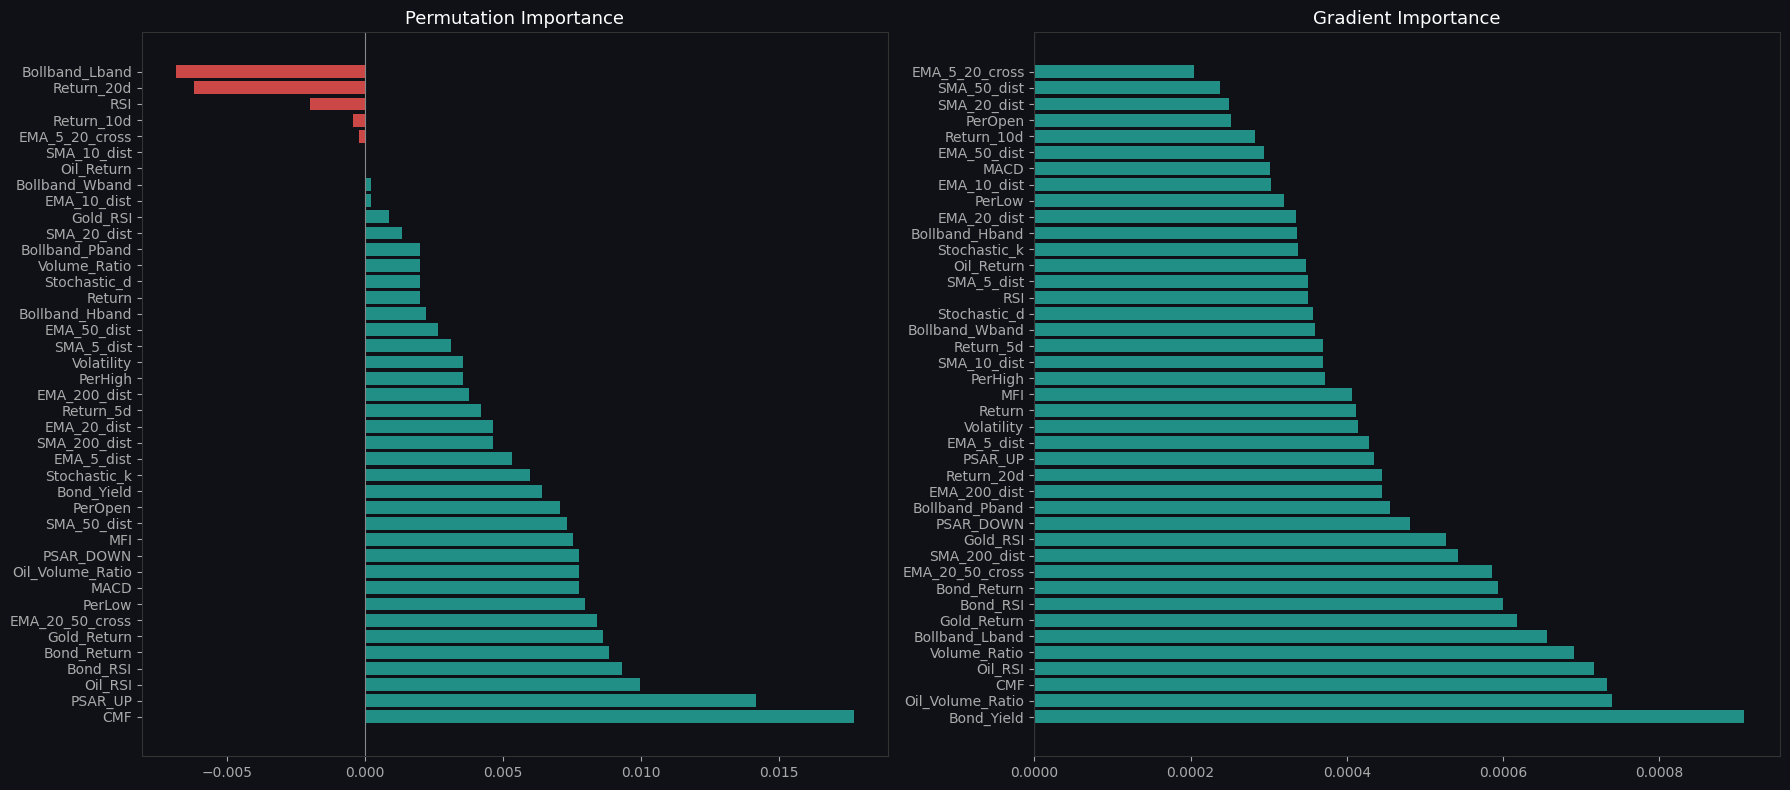

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#0f1117')

for ax, data, title in zip(
    [ax1, ax2],
    [importance, grad_importance],
    ['Permutation Importance', 'Gradient Importance']
):
    ax.set_facecolor('#0f1117')
    features = list(data.keys())
    scores   = list(data.values())
    colors   = ['#26a69a' if s > 0 else '#ef5350' for s in scores]

    bars = ax.barh(features, scores, color=colors, alpha=0.85)
    ax.set_title(title, color='white', fontsize=13)
    ax.tick_params(colors='#aaaaaa')
    ax.axvline(0, color='#888888', linewidth=0.8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

# Fuck around and find out


In [ ]:
def download_and_clean(ticker, start="2000-01-01"):
    df = yf.download(ticker, start=start, auto_adjust=True)
    df.columns = df.columns.droplevel(1)
    df.index.name = 'Date'
    df = df.reset_index()
    df['Date'] = pd.to_datetime(df['Date']).dt.normalize()
    return df

# Download all
df_sp500 = download_and_clean("GM") # Try this!
df_gold  = download_and_clean("GC=F")
df_oil   = download_and_clean("CL=F")
df_bond  = download_and_clean("^TNX")  # 10-year treasury yield

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
df = df_sp500.copy()

high, low, open, close = df['High'], df['Low'], df['Open'], df['Close']

# Returns
df['Return'] = df['Close'].pct_change()
df['PerOpen'] = df['Open'].pct_change()
df["PerHigh"] = df['High'].pct_change()
df['PerLow'] = df['Low'].pct_change()

# Volume
df['Volume_Ratio'] = df['Volume'] / df['Volume'].rolling(20).mean()

# Trend
df['SMA_5']  = ta.trend.sma_indicator(df['Close'], window=5)
df['SMA_10'] = ta.trend.sma_indicator(df['Close'], window=10)
df['SMA_20'] = ta.trend.sma_indicator(df['Close'], window=20)
df['SMA_50'] = ta.trend.sma_indicator(df['Close'], window=50)
df['SMA_200'] = ta.trend.sma_indicator(df['Close'], window=200)

# Instead of raw SMA, use distance from price as a percentage
df['SMA_5_dist']  = (df['Close'] - df['SMA_5'])  / df['Close']
df['SMA_10_dist'] = (df['Close'] - df['SMA_10']) / df['Close']
df['SMA_20_dist'] = (df['Close'] - df['SMA_20']) / df['Close']
df['SMA_50_dist'] = (df['Close'] - df['SMA_50']) / df['Close']
df['SMA_200_dist'] = (df['Close'] - df['SMA_200']) / df['Close']

# Add EMA indicators
df['EMA_5']  = ta.trend.ema_indicator(df['Close'], window=5)
df['EMA_10'] = ta.trend.ema_indicator(df['Close'], window=10)
df['EMA_20'] = ta.trend.ema_indicator(df['Close'], window=20)
df['EMA_50'] = ta.trend.ema_indicator(df['Close'], window=50)
df['EMA_200'] = ta.trend.ema_indicator(df['Close'], window=200)

# Normalize as distance from price (same as SMA)
df['EMA_5_dist']  = (df['Close'] - df['EMA_5'])  / df['Close']
df['EMA_10_dist'] = (df['Close'] - df['EMA_10']) / df['Close']
df['EMA_20_dist'] = (df['Close'] - df['EMA_20']) / df['Close']
df['EMA_50_dist'] = (df['Close'] - df['EMA_50']) / df['Close']
df['EMA_200_dist'] = (df['Close'] - df['EMA_200']) / df['Close']

# Positive = short EMA above long EMA (bullish), Negative = bearish
df['EMA_5_20_cross']  = df['EMA_5_dist']  - df['EMA_20_dist']
df['EMA_20_50_cross'] = df['EMA_20_dist'] - df['EMA_50_dist']

# Drop raw EMA
df = df.drop(columns=['EMA_5', 'EMA_10', 'EMA_20', 'EMA_50', 'EMA_200'])

# Drop the raw SMA columns
df = df.drop(columns=['SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'SMA_200'])

df['MACD'] = ta.trend.macd(df['Close'])
df['MACD'] = df['MACD'] / df['Close']

df['PSAR_DOWN'] = ta.trend.psar_down(high, low, close) / close
df['PSAR_UP'] = ta.trend.psar_up(high, low, close) / close

df['Bollband_Hband'] = ta.volatility.bollinger_hband(close) / close
df['Bollband_Lband'] = ta.volatility.bollinger_lband(close) / close
df['Bollband_Pband'] = ta.volatility.bollinger_pband(close) / close
df['Bollband_Wband'] = ta.volatility.bollinger_wband(close) / close

df['Stochastic_d'] = ta.momentum.stochrsi_d(close)
df['Stochastic_k'] = ta.momentum.stochrsi_k(close)

# Momentum
df['RSI'] = ta.momentum.rsi(df['Close'], window=14) / 100

# Volatility
df['Volatility'] = df['Return'].rolling(10).std()

# Target — next day up or down
df['Future_Up_1d'] = (df['Close'].shift(-1) > df['Close']).astype(int)

In [ ]:
df_gold['Gold_Return'] = df_gold['Close'].pct_change()
# df_gold['Gold_Volume_Ratio'] = df_gold['Volume'] / df_gold['Volume'].rolling(20).mean()
df_oil['Oil_Return']   = df_oil['Close'].pct_change()
df_oil['Oil_Volume_Ratio'] = df_oil['Volume'] / df_oil['Volume'].rolling(20).mean()
df_bond['Bond_Return'] = df_bond['Close'].pct_change()
df_bond['Bond_Yield']  = df_bond['Close']  / 10 # yield level is meaningful too

# Merge all
df = df.merge(df_gold[['Date', 'Gold_Return']], on='Date', how='left') \
       .merge(df_oil[['Date', 'Oil_Return', 'Oil_Volume_Ratio']],   on='Date', how='left') \
       .merge(df_bond[['Date', 'Bond_Return', 'Bond_Yield']], on='Date', how='left')

# Forward fill gaps (holidays etc.)
df = df.ffill().dropna().reset_index(drop=True)

print(df.shape)
df

(3676, 40)


Price,Date,Close,High,Low,Open,Volume,Return,PerOpen,PerHigh,PerLow,...,Stochastic_d,Stochastic_k,RSI,Volatility,Future_Up_1d,Gold_Return,Oil_Return,Oil_Volume_Ratio,Bond_Return,Bond_Yield
0,2011-09-02,16.419003,16.776099,16.166059,16.671946,14086700,-0.041685,-0.069738,-0.070103,-0.051506,...,0.833327,0.733113,0.352599,0.028013,0,0.026123,-0.027887,0.867152,-0.069897,0.1996
1,2011-09-06,15.950318,16.054471,15.533705,15.890802,14282500,-0.028545,-0.046854,-0.043015,-0.039116,...,0.699909,0.514312,0.329030,0.028785,1,-0.002028,-0.004974,0.918780,-0.008517,0.1979
2,2011-09-07,17.006721,17.140633,16.233012,16.233012,13412200,0.066231,0.021535,0.067655,0.045019,...,0.607105,0.573891,0.422700,0.035623,0,-0.029788,0.038596,0.952099,0.028802,0.2036
3,2011-09-08,16.724022,17.207590,16.545474,16.954648,11782500,-0.016623,0.044455,0.003906,0.019249,...,0.589227,0.679477,0.406351,0.035993,0,0.022159,-0.003246,1.051146,-0.024558,0.1986
4,2011-09-09,16.188374,16.701700,15.972627,16.634744,11920600,-0.032029,-0.018868,-0.029399,-0.034623,...,0.675448,0.772974,0.376628,0.037496,1,0.001079,-0.020326,1.116853,-0.035750,0.1915
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3671,2026-04-13,76.830002,76.860001,75.150002,75.610001,3970200,0.005365,-0.019453,-0.007874,-0.013002,...,0.919570,0.976826,0.541754,0.022911,1,-0.004095,0.025992,0.929328,-0.004633,0.4297
3672,2026-04-14,79.459999,79.860001,78.099998,78.629997,5859600,0.034231,0.039942,0.039032,0.039255,...,0.977012,0.977383,0.611791,0.024374,0,0.017417,-0.078724,0.868736,-0.009542,0.4256
3673,2026-04-15,77.779999,79.540001,77.760002,79.540001,6475600,-0.021143,0.011573,-0.004007,-0.004353,...,0.956142,0.914216,0.553587,0.025474,1,-0.005181,0.000110,0.667511,0.006109,0.4282
3674,2026-04-16,78.050003,78.349998,77.010002,77.589996,5615100,0.003471,-0.024516,-0.014961,-0.009645,...,0.910230,0.839090,0.560819,0.025458,1,-0.003042,0.037244,0.536895,0.006305,0.4309


In [ ]:
import torch

SEQUENCE_LENGTH = 90

target_cols  = ['Future_Up_1d']

n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df
val_df   = df
test_df  = df

test_prices = test_df['Close'].values[SEQUENCE_LENGTH:]
test_dates  = test_df['Date'].values[SEQUENCE_LENGTH:]

train_df = train_df.drop(columns=DROP_COLS)
val_df   = val_df.drop(columns=DROP_COLS)
test_df  = test_df.drop(columns=DROP_COLS)

feature_cols = [col for col in train_df.columns if col not in ['Date'] + target_cols]

# Normalize using train set only
train_features = torch.tensor(train_df[feature_cols].values, dtype=torch.float32)
mean = train_features.mean(dim=0)
std  = train_features.std(dim=0)
std[std == 0] = 1

def normalize_df(data, feature_cols, mean, std):
    df_norm = data.copy()
    df_norm[feature_cols] = (data[feature_cols].values - mean.numpy()) / std.numpy()
    return df_norm

train_df_norm = normalize_df(train_df, feature_cols, mean, std)
val_df_norm   = normalize_df(val_df,   feature_cols, mean, std)
test_df_norm  = normalize_df(test_df,  feature_cols, mean, std)

# Create sequences
X_train, y_train = create_sequences(train_df_norm, feature_cols, target_cols, SEQUENCE_LENGTH)
X_val,   y_val   = create_sequences(val_df_norm,   feature_cols, target_cols, SEQUENCE_LENGTH)
X_test,  y_test  = create_sequences(test_df_norm,  feature_cols, target_cols, SEQUENCE_LENGTH)

y_train = y_train.squeeze(1).long()
y_val   = y_val.squeeze(1).long()
y_test  = y_test.squeeze(1).long()

def to_one_hot(y, num_classes=2):
    return torch.zeros(len(y), num_classes).scatter_(1, y.unsqueeze(1), 1)

y_train = to_one_hot(y_train)
y_val   = to_one_hot(y_val)
y_test  = to_one_hot(y_test)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   | y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")
print(f"test_prices: {test_prices.shape} | test_dates: {test_dates.shape}")

X_train: torch.Size([3586, 90, 33]) | y_train: torch.Size([3586, 2])
X_val:   torch.Size([3586, 90, 33])   | y_val:   torch.Size([3586, 2])
X_test:  torch.Size([3586, 90, 33])  | y_test:  torch.Size([3586, 2])
test_prices: (3586,) | test_dates: (3586,)


In [ ]:
with torch.no_grad():
    output = model(X_test.to(device))
    preds   = output.argmax(dim=1)
    # print(preds)
    targets = y_test.argmax(dim=1).to(device)
    test_acc = (preds == targets).sum().item() / len(y_test)
    print(f"Predicted 1s: {(preds==1).sum().item()}")
    print(f"Predicted 0s: {(preds==0).sum().item()}")
    print(f"Actual 1s:    {(y_test.argmax(dim=1)==1).sum().item()}")
    print(f"Actual 0s:    {(y_test.argmax(dim=1)==0).sum().item()}")
    print(f"Test Accuracy: {test_acc:.4f}")

Predicted 1s: 2266
Predicted 0s: 1320
Actual 1s:    1840
Actual 0s:    1746
Test Accuracy: 0.5259


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

with torch.no_grad():
    output = model(X_test.to(device))
    preds  = output.argmax(dim=1).cpu().numpy()
    actual = y_test.argmax(dim=1).cpu().numpy()

# Full report
print(classification_report(actual, preds, target_names=['Down (0)', 'Up (1)']))

# Confusion matrix
cm = confusion_matrix(actual, preds)
print("Confusion Matrix:")
print(f"                Predicted Down  Predicted Up")
print(f"Actual Down     {cm[0][0]:^14}  {cm[0][1]:^12}")
print(f"Actual Up       {cm[1][0]:^14}  {cm[1][1]:^12}")

              precision    recall  f1-score   support

    Down (0)       0.52      0.39      0.45      1746
      Up (1)       0.53      0.65      0.59      1840

    accuracy                           0.53      3586
   macro avg       0.52      0.52      0.52      3586
weighted avg       0.52      0.53      0.52      3586

Confusion Matrix:
                Predicted Down  Predicted Up
Actual Down          683            1063    
Actual Up            637            1203    


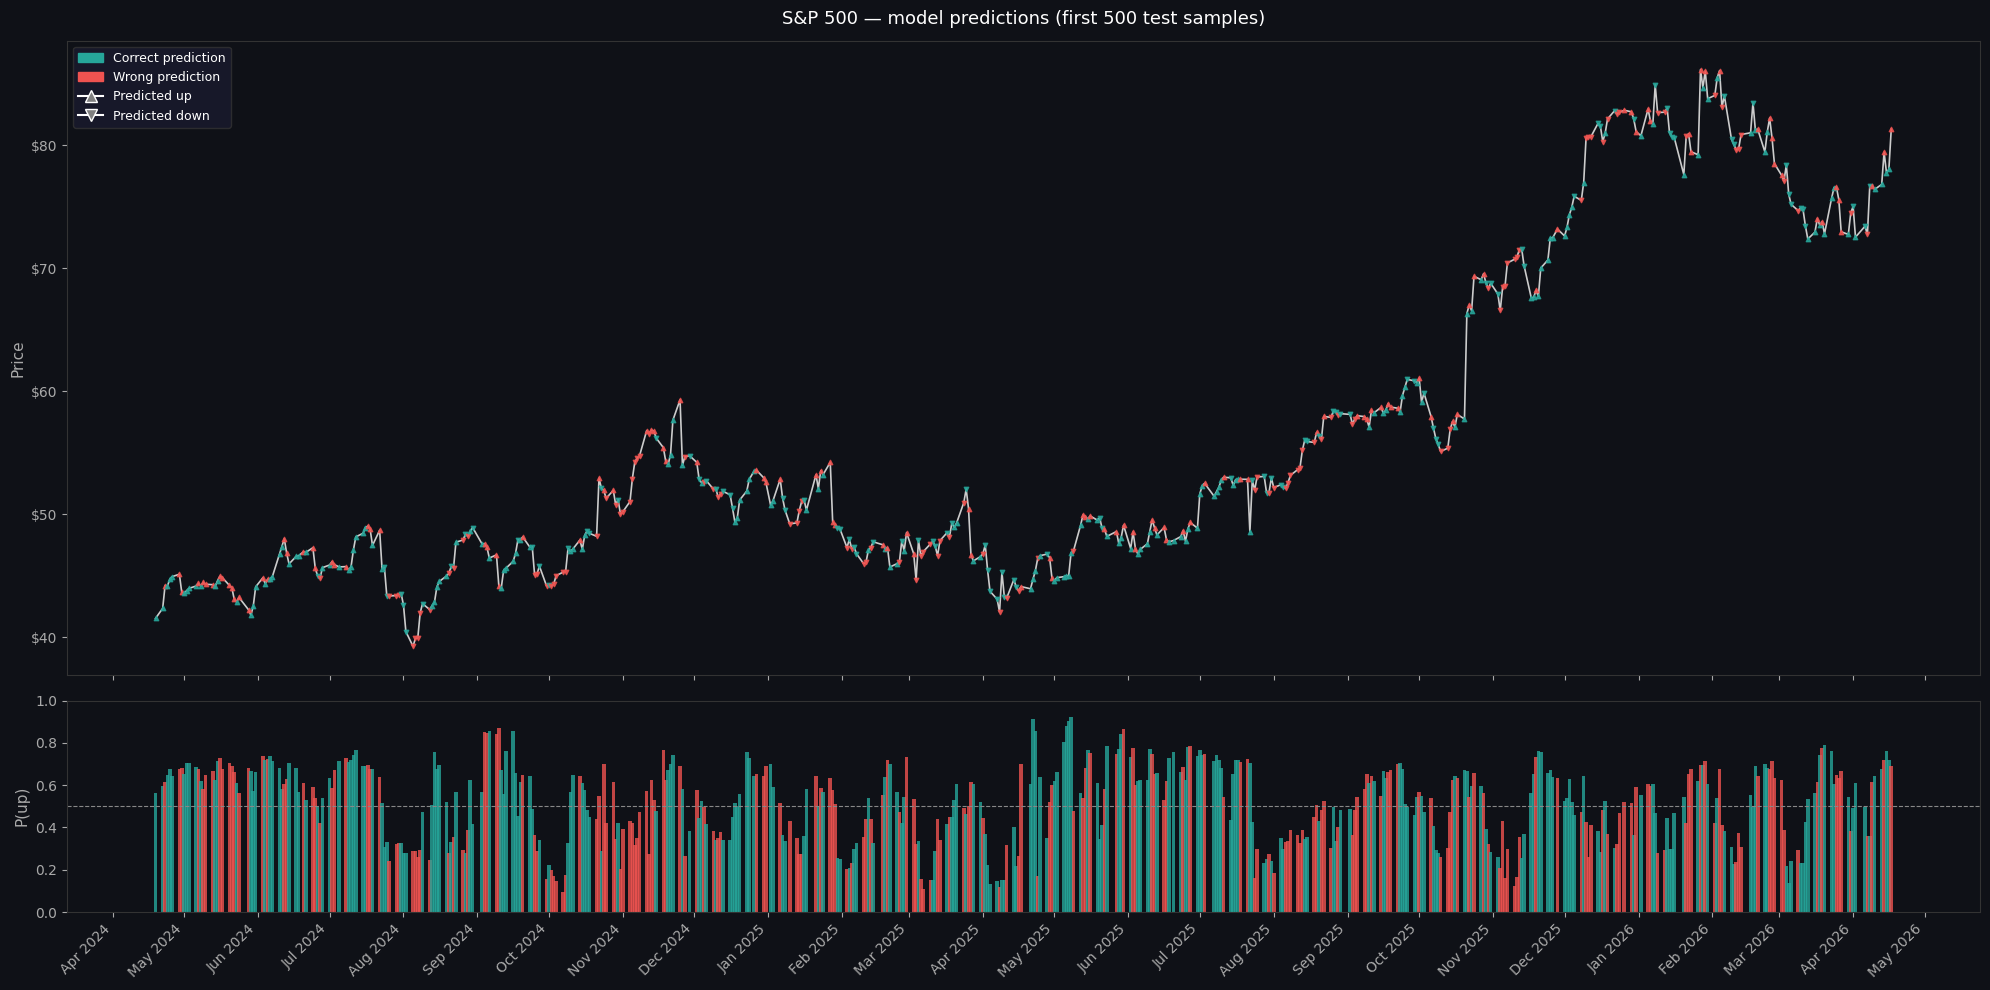

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

with torch.no_grad():
    output = model(X_test.to(device))
    probs  = output[:, 1].cpu().numpy()
    preds  = output.argmax(dim=1).cpu().numpy()
    actual = y_test.argmax(dim=1).cpu().numpy()

correct_mask = preds == actual
n_show = 500  # change this to see more

# Slice to n_show
dates  = pd.to_datetime(test_dates[-n_show:])
prices = test_prices[-n_show:]
p      = preds[-n_show:]
prob   = probs[-n_show:]
corr   = correct_mask[-n_show:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)
fig.patch.set_facecolor('#0f1117')
for ax in (ax1, ax2):
    ax.set_facecolor('#0f1117')
    ax.tick_params(colors='#aaaaaa')
    ax.yaxis.label.set_color('#aaaaaa')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

# --- Plot 1: Price line + prediction markers ---
ax1.plot(dates, prices, color='#cccccc', linewidth=1.2, zorder=1)

for i in range(len(dates)):
    if p[i] == 1 and corr[i]:      # predicted up, correct
        marker, color = '^', '#26a69a'
    elif p[i] == 0 and corr[i]:    # predicted down, correct
        marker, color = 'v', '#26a69a'
    elif p[i] == 1 and not corr[i]: # predicted up, wrong
        marker, color = '^', '#ef5350'
    else:                           # predicted down, wrong
        marker, color = 'v', '#ef5350'

    ax1.scatter(dates[i], prices[i], marker=marker, color=color,
                s=10, zorder=2, alpha=0.85)

ax1.set_ylabel('Price', fontsize=11)
ax1.set_title(f'S&P 500 — model predictions (first {n_show} test samples)',
              fontsize=13, color='white', pad=12)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

legend_patches = [
    mpatches.Patch(color='#26a69a', label='Correct prediction'),
    mpatches.Patch(color='#ef5350', label='Wrong prediction'),
    plt.Line2D([0],[0], marker='^', color='w', markerfacecolor='gray', markersize=8, label='Predicted up'),
    plt.Line2D([0],[0], marker='v', color='w', markerfacecolor='gray', markersize=8, label='Predicted down'),
]
ax1.legend(handles=legend_patches, fontsize=9, loc='upper left',
           facecolor='#1a1a2e', labelcolor='white', edgecolor='#333333')

# --- Plot 2: Confidence bar ---
bar_colors = ['#26a69a' if c else '#ef5350' for c in corr]
ax2.bar(dates, prob, color=bar_colors, width=1.5, alpha=0.8)
ax2.axhline(0.5, color='#888888', linestyle='--', linewidth=0.8)
ax2.set_ylabel('P(up)', fontsize=11)
ax2.set_ylim(0, 1)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45, ha='right', color='#aaaaaa')

plt.tight_layout()
plt.savefig('predictions.png', dpi=300, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
# Old pic btw, didn't update this :P